# Customer Segmentation Using Unsupervised Learning
# Problem Statement

Businesses often struggle to understand customer behavior and spending patterns, making it difficult to create effective marketing strategies. Without proper segmentation, companies may target all customers in the same way, leading to lower customer satisfaction and reduced sales performance.
This project aims to solve this problem by using machine learning techniques to group customers into different segments based on their demographic and spending behavior.

# Objective

The main objective of this project is to perform customer segmentation using K-Means Clustering on the Mall Customers dataset. The project identifies groups of customers with similar characteristics and provides data-driven marketing strategies for each segment.

Key objectives include:

Analyze customer data through Exploratory Data Analysis (EDA)        
Preprocess and clean the dataset                     
Apply K-Means clustering for segmentation                       
Visualize customer groups using PCA or t-SNE                              
Generate business insights and marketing recommendations                 

# Dataset Description and Loading

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE




In [7]:
df = pd.read_csv("Mall_Customers.csv")

In [8]:

print(df.head())
print(df.info())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


# Features:                                            
CustomerID → Unique customer identifier                                     
Gender → Male/Female                                       
Age → Customer age                                                 
Annual Income (k$) → Annual income in thousand dollars                                   
Spending Score (1-100) → Score assigned based on customer purchasing behavior                   

# Data Cleaning and Preprocessing
Steps Performed :                                     
Checked for missing values                            
Removed unnecessary columns like CustomerID                 
Encoded categorical variables (Gender)                 
Standardized numerical features for clustering                 

In [9]:
# Check Missing Values 
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


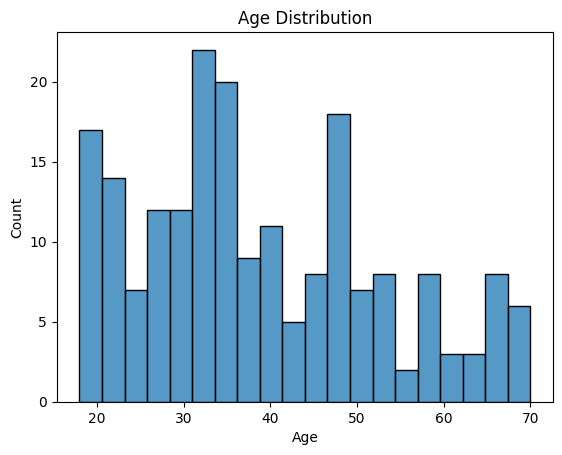

In [10]:
# Age Distribution


sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

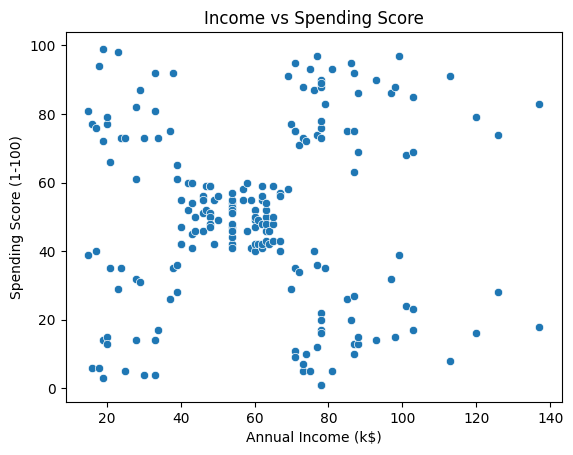

In [11]:
# Annual Income vs Spending Score
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

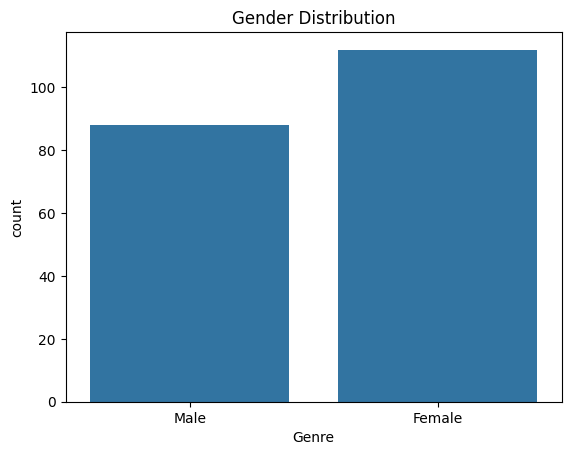

In [12]:
# Gender Distribution
sns.countplot(x='Genre', data=df)
plt.title("Gender Distribution")
plt.show()

#  Apply K-Means Clustering to Segment Customers
Feature Selection

We use:
    
Annual Income (k$)           
Spending Score (1-100)

In [13]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [14]:
# Feature Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

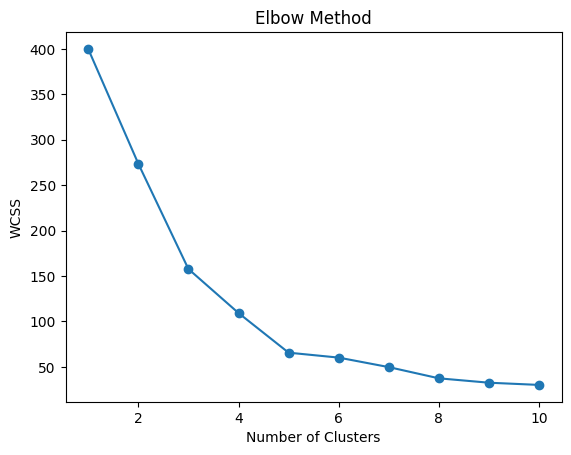

In [16]:
# Find Optimal Clusters using Elbow Method

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [19]:
# Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


c:\ProgramData\miniconda3\envs\my_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#  Use PCA or t-SNE to Visualize Clusters

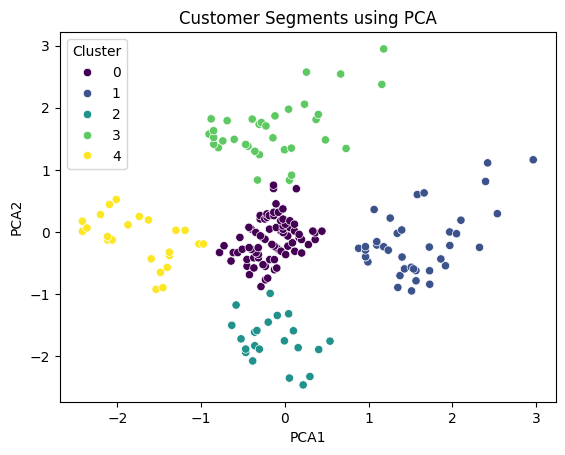

In [20]:
# PCA Visualization

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=df
)

plt.title("Customer Segments using PCA")
plt.show()

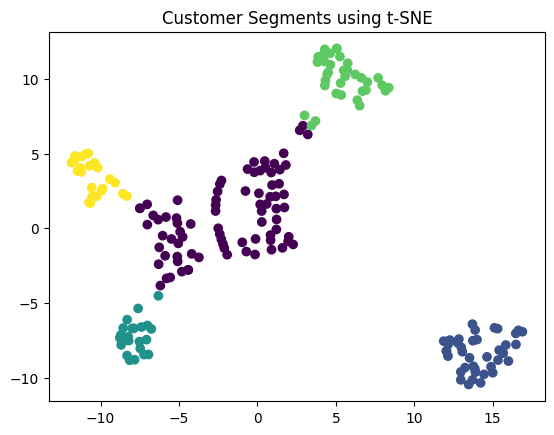

In [21]:
#t-SNE Visualization 
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

tsne_data = tsne.fit_transform(X_scaled)

plt.scatter(tsne_data[:,0], tsne_data[:,1], c=df['Cluster'])
plt.title("Customer Segments using t-SNE")
plt.show() 

4. Suggest Marketing Strategies for Each Segment              
Cluster	    -----     Customer Characteristics    --------	                    Marketing Strategy                                       
Cluster 0	------     High Income, High Spending	-------          Offer VIP memberships, luxury products, exclusive discounts                        
Cluster 1  -------   High Income, Low Spending	   --------       Use personalized ads and premium product recommendations                       
Cluster 2	 ----    Low Income, High Spending	 -----------         Provide discounts, cashback offers, seasonal promotions                            
Cluster 3    -----	 Low Income, Low Spending	      -------    Promote affordable products and bundle deals                           
Cluster 4	--------     Average Income & Spending    --------  Maintain engagement with loyalty programs and email marketing                       

# Final Insights
# Key Findings                                            
Customers can be divided into multiple spending groups.                      
Income alone does not determine spending behavior.                                     
K-Means clustering successfully identifies meaningful customer segments.                            
PCA and t-SNE help visualize hidden patterns in customer data.                 
# Business Benefits                              
Better customer targeting                                      
Improved marketing campaigns                                         
Increased customer retention                                  
Higher sales through personalized offers                        
# Skills Gained                        
Unsupervised Learning using K-Means                
Customer Segmentation                        
Data Visualization                               
Dimensionality Reduction (PCA, t-SNE)                          
Business Strategy Development                                   